# K-Nearest Neighbors (KNN) Algorithm

## KNN for Classification

We will use the famous Iris dataset for this classification task.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

### Data Splitting and Scaling

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Finding the optimal K value (Elbow Method)

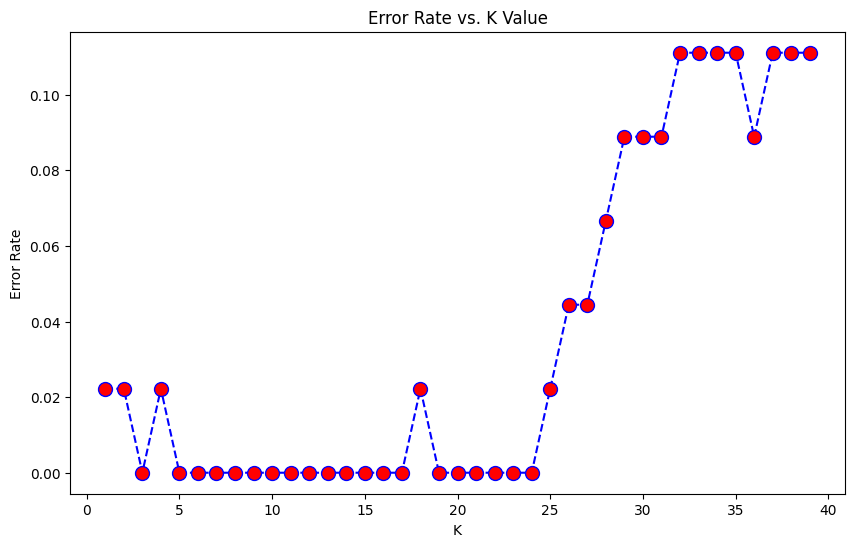

In [3]:
error_rate = []
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

From the plot, we can see that the error rate is lowest for a K value around 3-10. We'll choose K=5 for this example.

### Training the KNN Model

In [4]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Predictions and Evaluation

In [5]:
y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### Visualizing Decision Boundaries

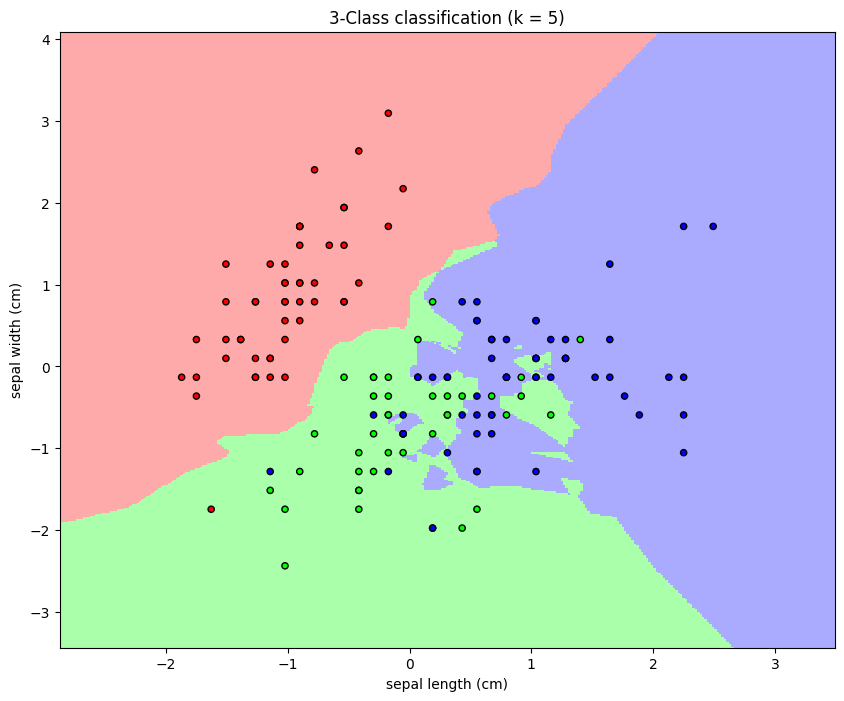

In [6]:
from matplotlib.colors import ListedColormap

# For visualization, we'll only use two features
X_vis = iris.data[:, :2]
y_vis = iris.target

# Scale features
X_vis = StandardScaler().fit_transform(X_vis)

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis, y_vis)

h = .02  # step size in the mesh
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("3-Class classification (k = 5)")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

## KNN for Regression

Now, let's see how to use KNN for a regression problem. We'll use the Boston Housing dataset.

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Load dataset
housing = fetch_california_housing()
X_reg = housing.data
y_reg = housing.target

### Data Splitting and Scaling

In [8]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Scale the features
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

### Finding the optimal K value (Elbow Method)

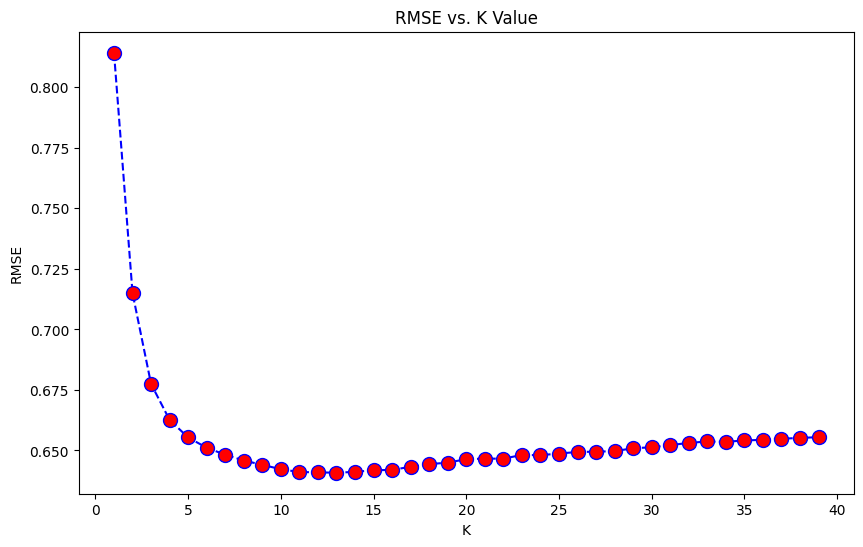

In [9]:
rmse_val = [] 
for K in range(1, 40):
    model = KNeighborsRegressor(n_neighbors=K)
    model.fit(X_train_reg, y_train_reg)
    pred=model.predict(X_test_reg)
    error = np.sqrt(mean_squared_error(y_test_reg,pred)) 
    rmse_val.append(error)

plt.figure(figsize=(10,6))
plt.plot(range(1,40), rmse_val, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('RMSE vs. K Value')
plt.xlabel('K')
plt.ylabel('RMSE')
plt.show()

From the plot, the RMSE is lowest for K around 5-10. We'll choose K=7.

### Training the KNN Regressor

In [10]:
knn_reg = KNeighborsRegressor(n_neighbors=7)
knn_reg.fit(X_train_reg, y_train_reg)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Predictions and Evaluation

In [11]:
y_pred_reg = knn_reg.predict(X_test_reg)

print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))

RMSE: 0.6482416021150119


### Visualizing Predictions

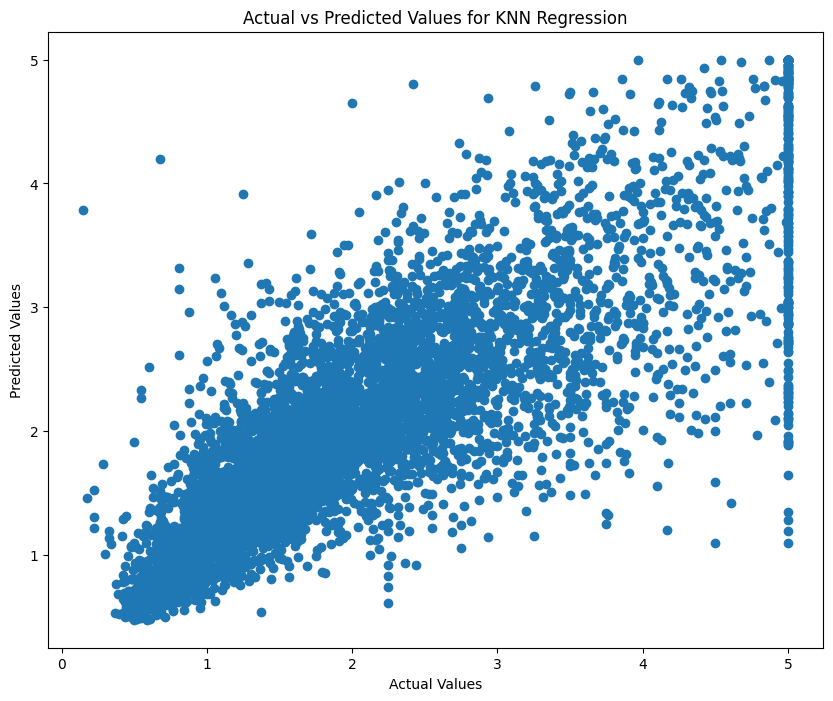

In [12]:
plt.figure(figsize=(10,8))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values for KNN Regression')
plt.show()

## Distance Metrics for KNN

KNN algorithm uses distance measures in order to find the k-nearest neighbors. There are many different distance metrics, but some of the most common are:

### 1. Euclidean Distance
This is the most common distance metric used in KNN. It is the straight-line distance between two points.
The formula is:  `sqrt(sum i to n (xi - yi)^2)`

### 2. Manhattan Distance
This distance is the sum of the absolute differences of their Cartesian coordinates.
The formula is: `sum i to n |xi - yi|`

### How to choose the distance metric?
You can specify the distance metric to be used in the `KNeighborsClassifier` or `KNeighborsRegressor` by using the `metric` parameter. For example:
`KNeighborsClassifier(n_neighbors=5, metric='manhattan')`

## Pros and Cons of KNN

### Pros
* **Simple to understand and implement:** KNN is a very simple algorithm to understand and implement.
* **No training phase:** KNN is a lazy learner, which means it doesn't have a training phase. The data is the model.
* **Good for multi-class problems:** It can be naturally used for multi-class classification problems.
* **Flexible to feature/distance choice:** You can use any distance metric or feature representation.

### Cons
* **Computationally expensive:** The testing phase of KNN is computationally expensive because it has to compute the distance of the test point to all training points.
* **Needs feature scaling:** Features with high magnitudes will weigh more than features with low magnitudes. So, it is important to scale the features.
* **Sensitive to irrelevant features:** KNN is very sensitive to irrelevant features.
* **Curse of dimensionality:** As the number of dimensions increases, the distance between any two points in the space becomes very large.